In [2]:
import numpy as np
import matplotlib.pyplot as plt
import vpython as vp
import random as rd
mc = "mediumorchid"
import warnings
warnings.filterwarnings('ignore')

<IPython.core.display.Javascript object>

## Ejercicio 9 - el atractor de Lorenz.

El atractor de Lorenz es un sistema dinámico determinista tridimensional no lineal dado por la ecuaciones:

$$\frac{\text{d}x}{\text{d}t}=\sigma(y-x),\quad \frac{\text{d}y}{\text{d}t}=rx-y-xz,\quad \frac{\text{d}z}{\text{d}t}=xy-bz,$$

que describe los efectos de convección que se producen en las ecuaciones dinámicas de la atmósfera terrestre, y es una de los ejemplos más claros de caos determinista, la aparición de movimiento aleatorio sin que la aleatoriedad se introduzca en las ecuaciones (otro de esos ejemplos son las ecuaciones de recursividad de la práctica 1).

1. Escribir un programa que resuelve el atractor de Lorenz para el caso $\sigma=10$, $r=28$ y $b=8/3$ para el intervalo $t\in[0,50]$ con las condiciones iniciales $(x,y,z)=(0,1,0)$. Representar el valor de x,y,z con el tiempo.


2. Representar z con respecto a x. Representa el atractor extraño de Lorenz que tiene forma de mariposa asimétrica.

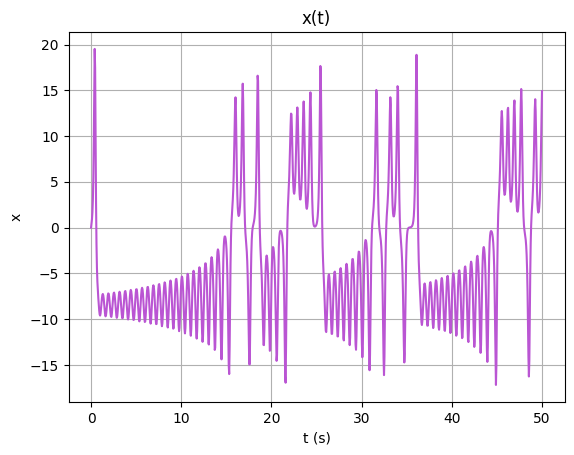

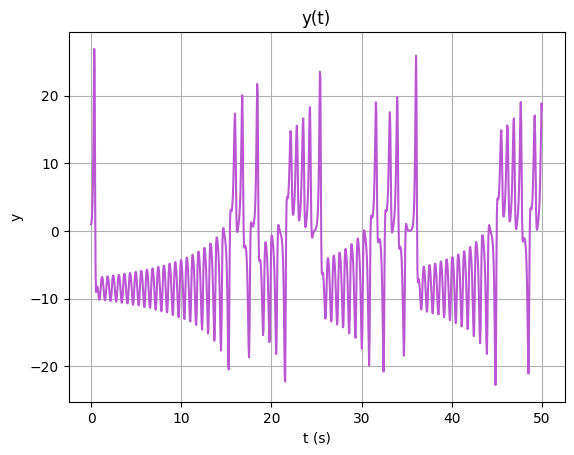

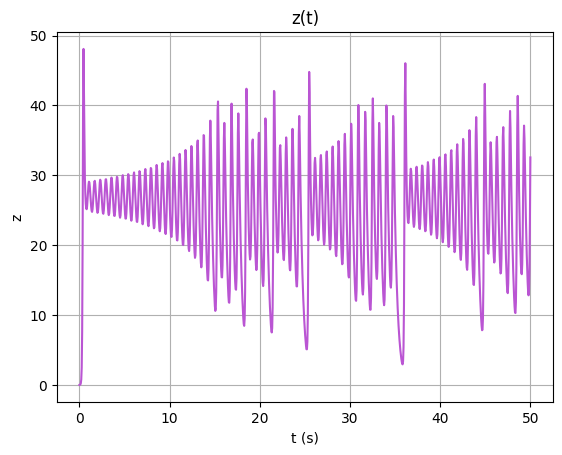

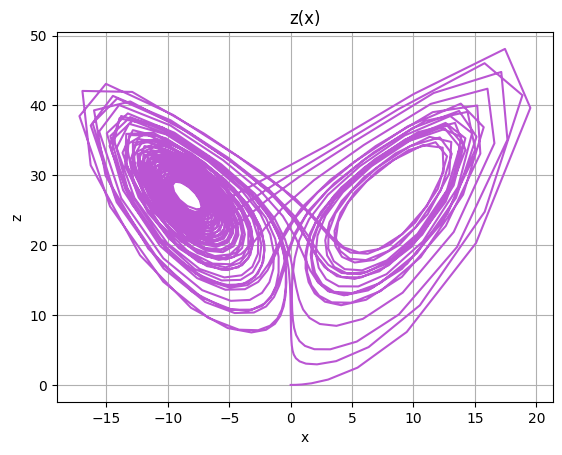

In [3]:
sigma = 10.0
r_val = 28.0
b = 8 / 3

x0, y0, z0 = 0, 1, 0
r = np.array([x0, y0, z0], float)

def F(r, t):
    x = r[0]
    y = r[1]
    z = r[2]
    fx = sigma * (y - x)
    fy = r_val * x - y - x * z
    fz = x * y - b * z
    return np.array([fx, fy, fz], float)

def lorenz_attractor(F, a, b, N, r):
    h = (b - a) / N
    time = np.linspace(a, b, N)
    xp, yp, zp = [], [], []
    r = np.array(r, float)

    for t in time:
        xp.append(r[0])
        yp.append(r[1])
        zp.append(r[2])

        k1 = h * F(r, t)
        k2 = h * F(r + k1 / 2, t + h / 2)
        k3 = h * F(r + k2 / 2, t + h / 2)
        k4 = h * F(r + k3, t + h)
        r += (k1 + 2 * k2 + 2 * k3 + k4) / 6
    return time, xp, yp, zp

t, x, y, z = lorenz_attractor(F, 0, 50, 1000, r)

plt.plot(t, x, color = mc)
plt.title('x(t)')
plt.xlabel('t (s)')
plt.ylabel('x')
plt.grid()
plt.show()

plt.plot(t, y, color = mc)
plt.title('y(t)')
plt.xlabel('t (s)')
plt.ylabel('y')
plt.grid()
plt.show()

plt.plot(t, z, color = mc)
plt.title('z(t)')
plt.xlabel('t (s)')
plt.ylabel('z')
plt.grid()
plt.show()

plt.plot(x, z, color = mc)
plt.title('z(x)')
plt.xlabel('x')
plt.ylabel('z')
plt.grid()
plt.show()
